In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/DL_final_df.csv')

In [3]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Desired sample sizes based on % targets
target_counts = {
    1: 350000,
    2: 470000,
    3: 620000,
    4: 800000,
    5: 980000
}

# Apply sampling
sampled = []

for rating, count in target_counts.items():
    group = df[df['rating'] == rating]
    sampled.append(group.iloc[:count])  # get top N

DL_final_df = pd.concat(sampled).reset_index(drop=True)

# Check result
print(DL_final_df['rating'].value_counts(normalize=True) * 100)

rating
5    30.434783
4    24.844720
3    19.254658
2    14.596273
1    10.869565
Name: proportion, dtype: float64


In [ ]:
df['rating'].value_counts()

rating
5    980000
4    800000
3    620000
2    470000
1    350000
Name: count, dtype: int64

C:\Users\SIDHARTH\AppData\Local\Temp\ipykernel_9036\2873943706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=df, palette="viridis",legend=False)


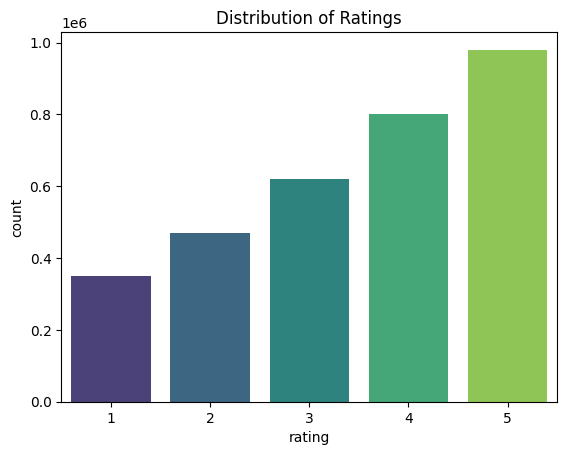

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="rating", data=df, palette="viridis",legend=False)
plt.title("Distribution of Ratings")
plt.show()


In [6]:
df.head(5)

,rating,review
0,5,i am only way through this book i have already...
1,2,i sometimes do like my disbelief suspended but...
2,2,phoned it in
3,3,there is no doubting that thomas fleming is a ...
4,5,all i can say for damned is wow what a sequel ...


In [7]:
import numpy as np
def avg_word_length(text):
    if pd.isnull(text): # Check for NaN values
      return 0
    text = str(text)  # Convert to string
    words = text.split()
    if len(words) == 0:
        return 0
    return np.mean([len(w) for w in words])

df["avg_word_length"] = df["review"].apply(avg_word_length)

print(df["avg_word_length"].describe())

count    3.220000e+06
mean     4.515294e+00
std      7.570767e-01
min      0.000000e+00
25%      4.133333e+00
50%      4.431535e+00
75%      4.805556e+00
max      5.385000e+02
Name: avg_word_length, dtype: float64


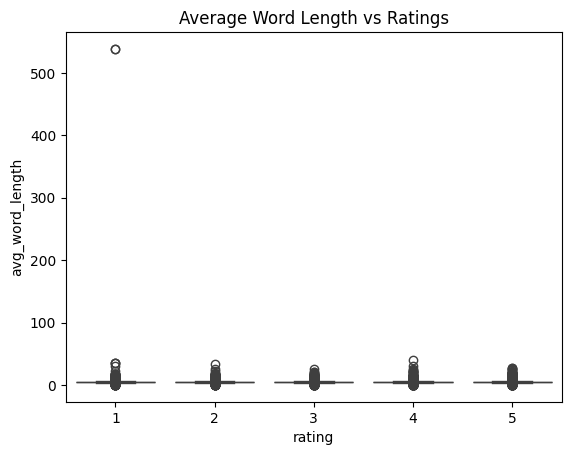

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="rating", y="avg_word_length", data=df)
plt.title("Average Word Length vs Ratings")
plt.show()

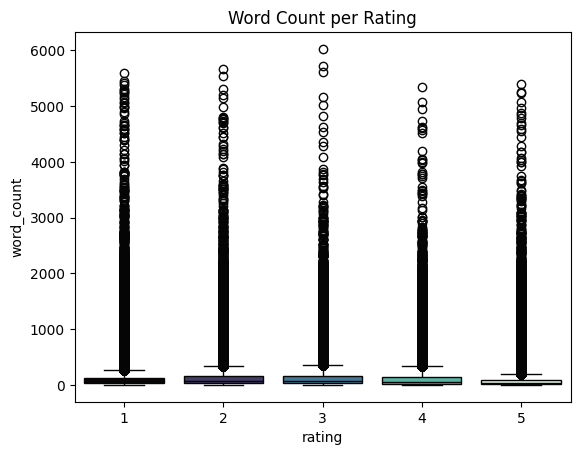

In [11]:
import re
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataframe if it's not already loaded
try:
    df.head()
except NameError:
    df = pd.read_csv('/content/drive/MyDrive/DL_final_df.csv')

def word_count(text):
    if pd.isnull(text):
        return 0
    text = str(text)
    words = text.split()
    return len(words)

df["word_count"] = df["review"].apply(word_count)

sns.boxplot(x="rating", y="word_count", data=df, hue="rating", palette="mako", legend=False)
plt.title("Word Count per Rating")
plt.show()

Text Cleaning & Tokenization of Reviews

In [12]:
import re
from collections import Counter
import pandas as pd

# Load the dataframe if it's not already loaded
try:
    df.head()
except NameError:
    df = pd.read_csv('/content/drive/MyDrive/DL_final_df.csv')

# Clean and join all reviews
all_text = " ".join(df["review"].fillna("").astype(str).str.lower())

# Remove non-alphabet characters
all_text = re.sub(r"[^a-z\s]", "", all_text)

# Tokenize into words
words = all_text.split()

Ratings Distribution (Pie Chart)

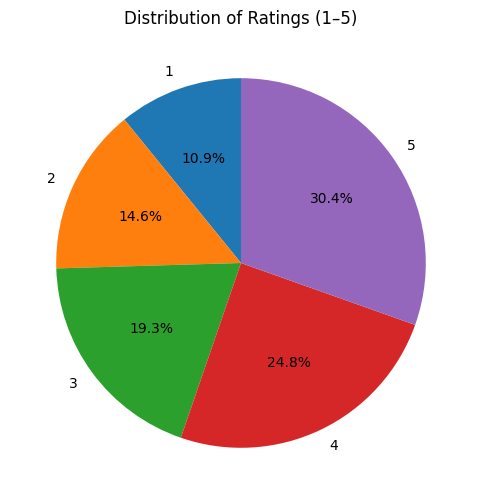

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe if it's not already loaded
try:
    df.head()
except NameError:
    df = pd.read_csv('/content/drive/MyDrive/DL_final_df.csv')


rating_counts = df['rating'].value_counts().sort_index()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Ratings (1–5)")
plt.show()

In [14]:
df.shape

(3220000, 4)

20 Most Frequent Words from Reviews

In [4]:
import re
from collections import Counter
import pandas as pd

# Load the dataframe if it's not already loaded
try:
    df.head()
except NameError:
    df = pd.read_csv('/content/drive/MyDrive/DL_final_df.csv')

# Clean and join all reviews
all_text = " ".join(df["review"].fillna("").astype(str).str.lower())

# Remove non-alphabet characters
all_text = re.sub(r"[^a-z\s]", "", all_text)

# Tokenize into words
words = all_text.split()

# Count frequency
word_freq = Counter(words)

# Get top 20 words
most_common_words = word_freq.most_common(20)
print(most_common_words)

[('the', 17694934), ('and', 9968206), ('to', 8787554), ('a', 8672555), ('of', 8278769), ('i', 7227150), ('is', 5272284), ('in', 4984232), ('book', 4853590), ('it', 4586243), ('this', 4444903), ('that', 4091459), ('was', 3281288), ('for', 2921000), ('but', 2519557), ('with', 2516753), ('as', 2232665), ('read', 2143519), ('not', 2081882), ('her', 1937802)]


20 Most Common Words in Reviews (Word Frequency Analysis)

/tmp/ipython-input-2566418774.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="word", data=wc_df, palette="viridis")


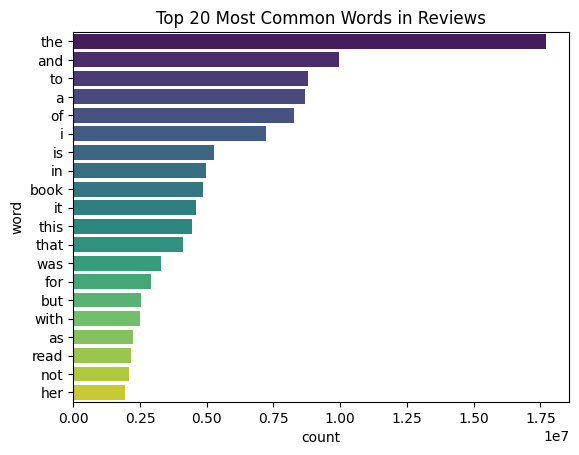

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from collections import Counter

# Load the dataframe if it's not already loaded
try:
    df.head()
except NameError:
    df = pd.read_csv('/content/drive/MyDrive/DL_final_df.csv')

# Clean and join all reviews
all_text = " ".join(df["review"].fillna("").astype(str).str.lower())

# Remove non-alphabet characters
all_text = re.sub(r"[^a-z\s]", "", all_text)

# Tokenize into words
words = all_text.split()

# Count frequency
word_freq = Counter(words)

# Get top 20 words
most_common_words = word_freq.most_common(20)

# Convert to DataFrame for plotting
wc_df = pd.DataFrame(most_common_words, columns=["word", "count"])

sns.barplot(x="count", y="word", data=wc_df, palette="viridis")
plt.title("Top 20 Most Common Words in Reviews")
plt.show()

Ratings Distribution Visualization (Pie Chart).

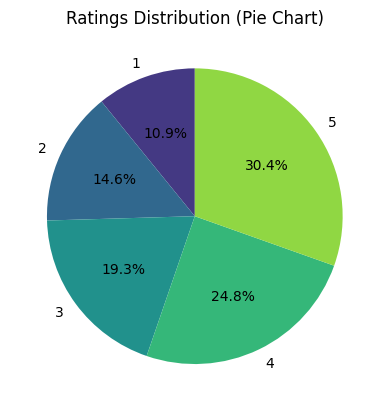

In [6]:
# Count ratings
rating_counts = df['rating'].value_counts().sort_index()

# Pie chart
plt.pie(rating_counts,
        labels=rating_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=sns.color_palette("viridis", len(rating_counts)))

plt.title("Ratings Distribution (Pie Chart)")
plt.show()


Sentiment Distribution Visualization (Bar & Pie Charts)

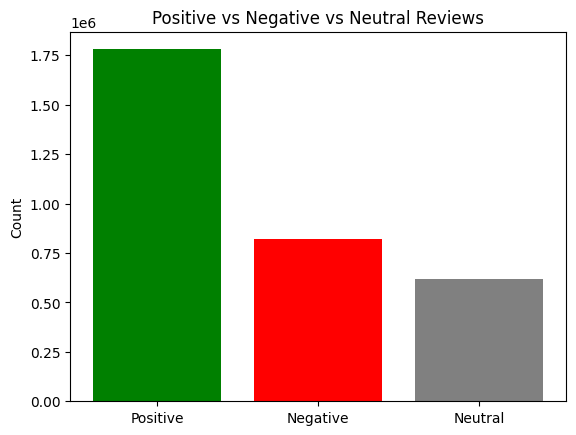

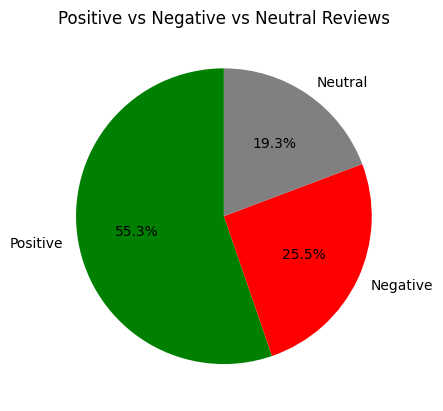

In [7]:
import matplotlib.pyplot as plt
# Define categories
df["sentiment_label"] = df["rating"].apply(
    lambda r: "Positive" if r >= 4 else ("Negative" if r <= 2 else "Neutral")
)

sentiment_counts = df["sentiment_label"].value_counts()

# Bar Chart
plt.bar(sentiment_counts.index, sentiment_counts.values, color=["green","red","gray"])
plt.title("Positive vs Negative vs Neutral Reviews")
plt.ylabel("Count")
plt.show()

# Pie Chart
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct="%1.1f%%",
        colors=["green","red","gray"], startangle=90)
plt.title("Positive vs Negative vs Neutral Reviews")
plt.show()


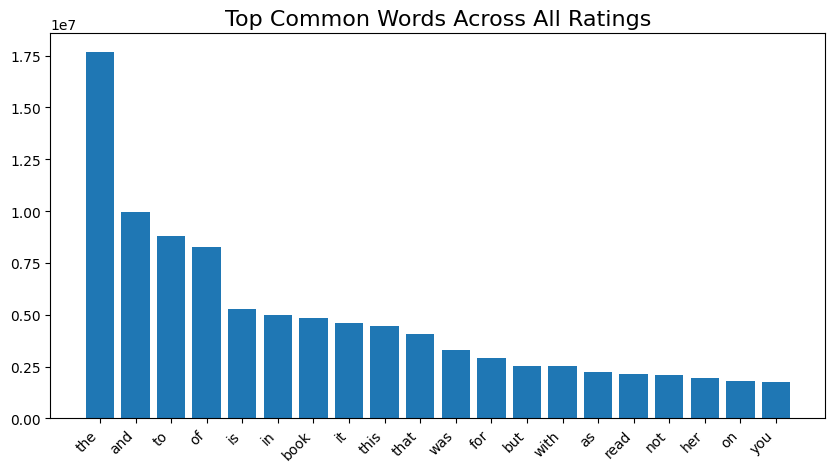

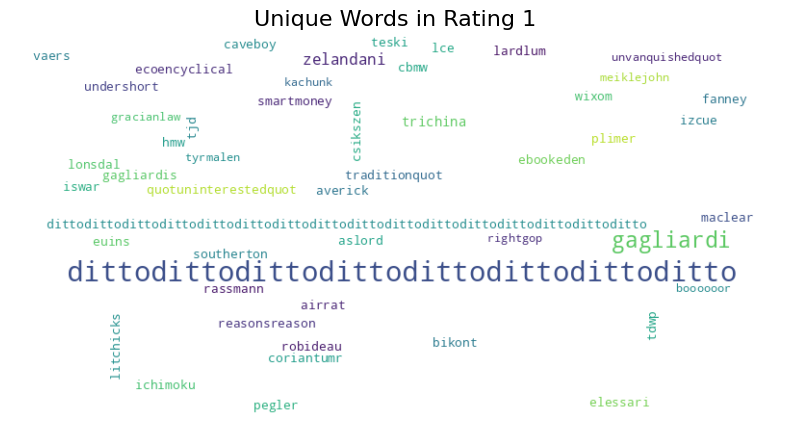

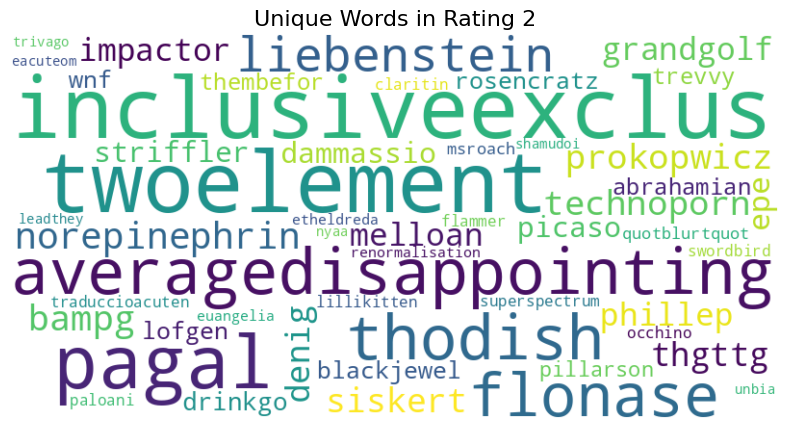

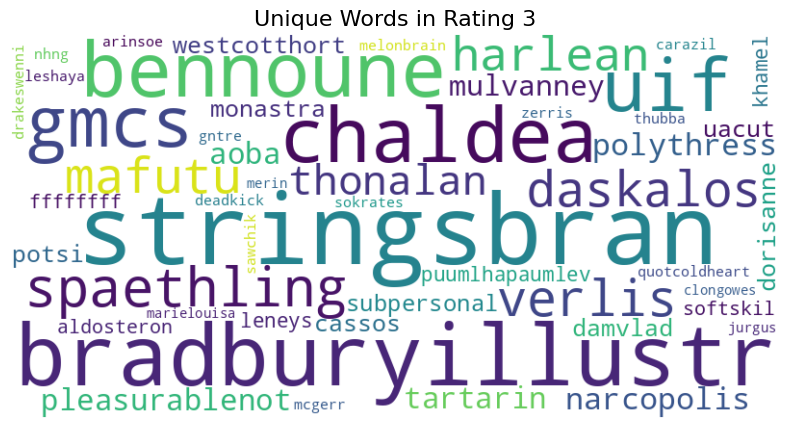

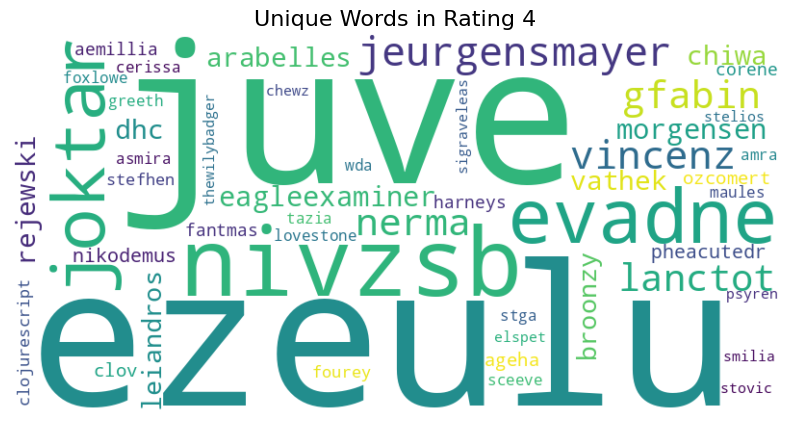

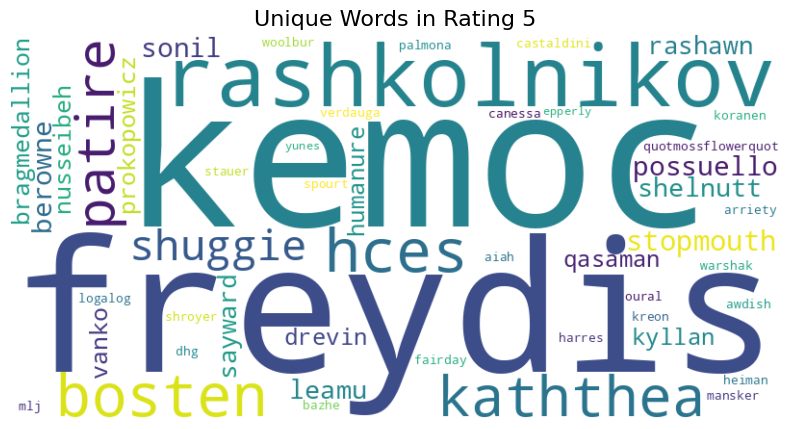

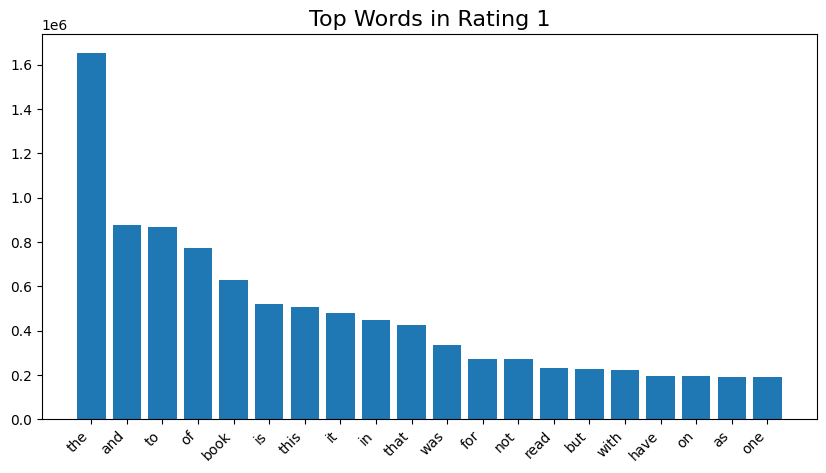

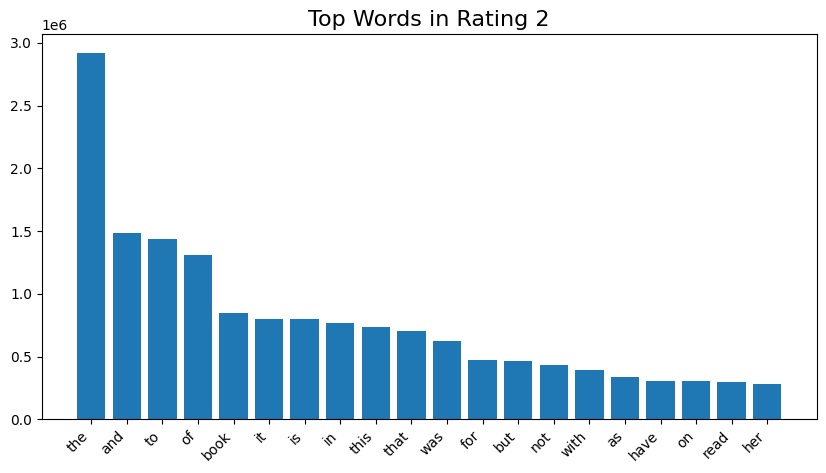

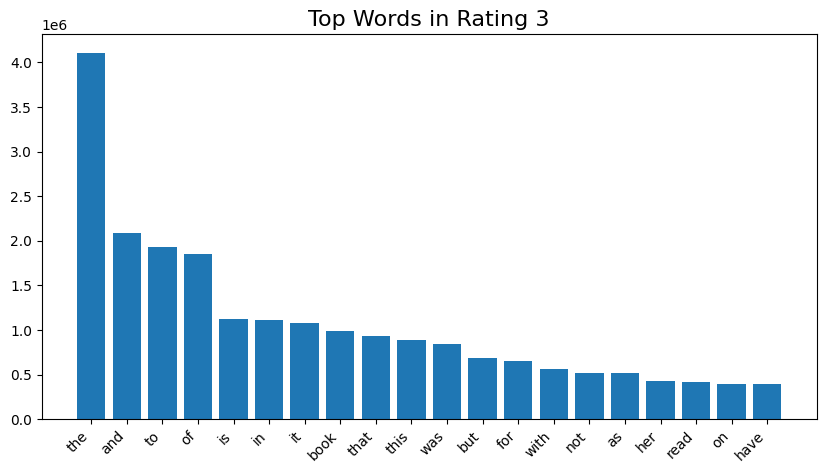

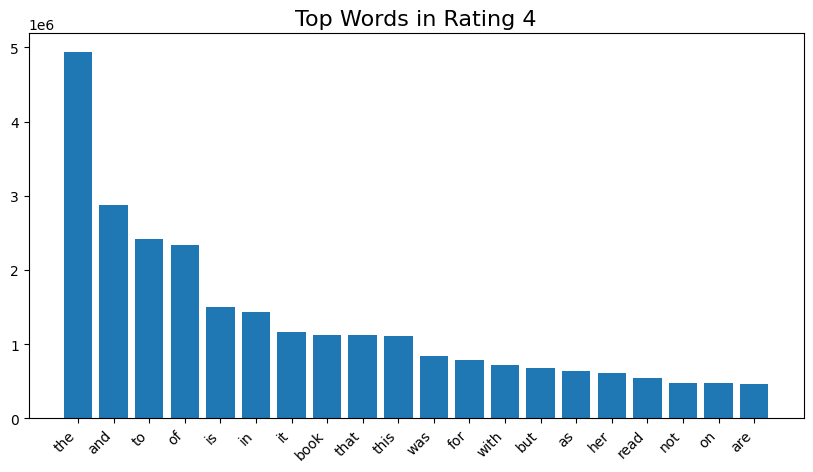

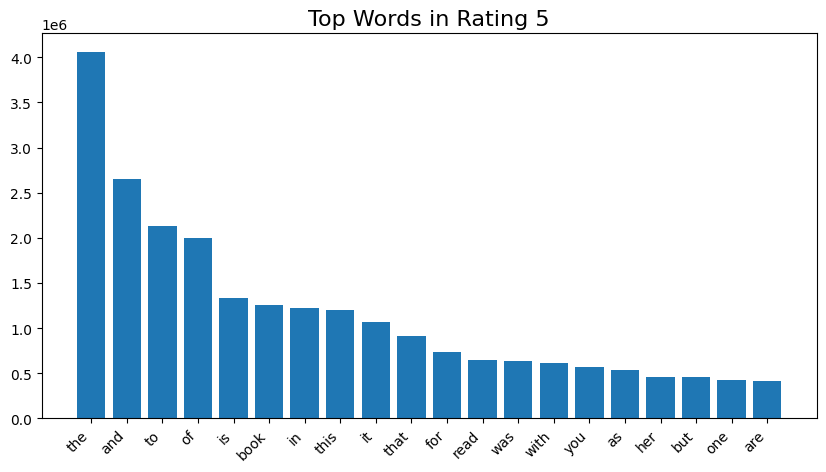

In [12]:
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from multiprocessing import Pool, cpu_count
import pandas as pd # Import pandas

# Tokenizer (fast regex)
def tokenize(text):
    return re.findall(r"\b[a-zA-Z]{2,}\b", str(text).lower())

# Function to count words for one rating (parallelized)
def count_words_for_rating(rating):
    # Use 'df' instead of 'final_merge_df'
    texts = df.loc[df["rating"] == rating, "review"].dropna() # Use 'review' column and handle NaN
    counter = Counter()
    for review in texts:
        counter.update(tokenize(review))
    return rating, counter

# Run in parallel
# Use 'df' instead of 'final_merge_df'
ratings = sorted(df["rating"].unique())
with Pool(cpu_count()) as p:
    results = p.map(count_words_for_rating, ratings)

# Collect results into dictionary
word_counts = dict(results)

# Sets for unique/common
word_sets = {r: set(c.keys()) for r, c in word_counts.items()}
common_words = set.intersection(*word_sets.values())
unique_words = {
    r: word_sets[r] - set.union(*(s for rr, s in word_sets.items() if rr != r))
    for r in word_sets
}

# --- Visualization ---
def plot_wordcloud(counter, title, top_n=50):
    wc = WordCloud(width=800, height=400, background_color="white")
    wc.generate_from_frequencies(dict(counter.most_common(top_n)))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

def plot_bar(counter, title, top_n=20):
    top_items = counter.most_common(top_n)
    words, counts = zip(*top_items)
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts)
    plt.xticks(rotation=45, ha="right")
    plt.title(title, fontsize=16)
    plt.show()

# 1. Common words across all ratings
plot_bar(Counter({w: sum(word_counts[r][w] for r in word_counts) for w in common_words}),
         "Top Common Words Across All Ratings")

# 2. Unique words per rating
for r in word_counts:
    if unique_words[r]:
        plot_wordcloud(Counter({w: word_counts[r][w] for w in unique_words[r]}),
                       f"Unique Words in Rating {r}")

# 3. Top words per rating
for r in word_counts:
    plot_bar(word_counts[r], f"Top Words in Rating {r}")

In [9]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 14.0 MB/s eta 0:00:00
